# Proyek Analisis Data: [E-Comerce Public Dataset]
- **Nama:** Dea Cipta Ningrum Aimanta Putri
- **Email:** deaciptaningrum090@gmail.com
- **ID Dicoding:** CDCC525D6X0222

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1**
Bagaimana jumlah order di setiap bulannya dan kapan terjadi peningkatan atau penurunan signifikan selama 2017 - 2018
- **Pertanyaan 2**
Kota mana yang memiliki jumlah pelanggan terbanyak selama 2017 - 2018 dan berpotensi menjadi target utama strategi pemasaran

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [6]:
orders = pd.read_csv('olist_orders_dataset.csv')
customer = pd.read_csv('olist_customers_dataset.csv')

**Insight:**
- Dilakukan proses pengambilan data dari dua dataset utama, yaitu order dan customer(Pelanggan).
- Kedua dataset dipilih karena saling berhubungan dan dapat digunakan untuk menganalisis perilaku pelanggan

### Assessing Data

In [7]:
orders.info()
orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- function digunakan untuk melihat jumlah data keseluruhan dan menghitung missing value di setiap kolom
- Berdasarkan Output yang tampil, dataset order memiliki 99.441 baris data dengan 8 kolom. Keseluruhan kolom masih bertipe objek, termasuk kolom yang seharusnya berupa tanggal (datetime), sehingga perlu dilakukannya konversi ke tipe data sebenarnya
- Berdasarkan Output dari pengecekan missing value, terdapat beberapa kolom yang memiliki data kosong, terutama kolom yang berkaitan dengan proses pengiriman.

### Cleaning Data

In [8]:
orders.dropna(inplace=True)

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])


**Insight:**
- Dikarenakan masih banyaknya kolom yang memiliki data kosong atau hilang, diperlukannya pembersihan data, sehingga dataset lebih siap untuk digunakan dalam tahap explorasi dan analisis berikutnya.
- Dilakukannya konversi tipe data pada koolom order_purchose_timestamp, yaitu berubah dari object ke datetime.


## Exploratory Data Analysis (EDA)

### Explore ...

In [10]:
df = orders.merge(customer, on='customer_id', how='left')

**Insight:**
- Dilakukannya proses penggabungan dataset menggunakan left join, sehingga seluruh data pada dataset order tetap dipertahankan.
- Penggabungan bertujuan menghubungkan informasi transaksi dengan data pelanggan, sehingga dataset yang dihasilkan menjadi lebih lengkap dan dapat digunakan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Bagaimana jumlah order di setiap bulannya dan kapan terjadi peningkatan atau penurunan signifikan selama 2017

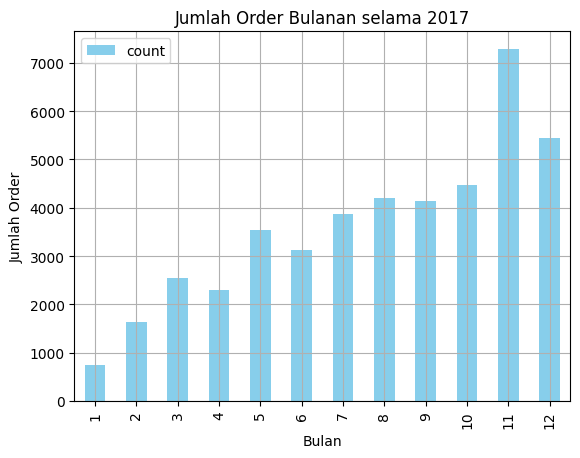

In [31]:
df_2017 = df[(df['order_purchase_timestamp'] >= '2017-01-01') &
             (df['order_purchase_timestamp'] <= '2017-12-31')].copy()

df_2017['month'] = df_2017['order_purchase_timestamp'].dt.month

monthly_orders = df_2017.groupby('month').size().reset_index(name='count')

monthly_orders.plot(x='month', y='count', kind='bar', color='skyblue')
plt.title('Jumlah Order Bulanan selama 2017')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')
plt.grid(True)
plt.show()

### Pertanyaan 2:
Kota mana yang memiliki jumlah pelanggan terbanyak selama 2017 - 2018 dan berpotensi menjadi target utama strategi pemasaran

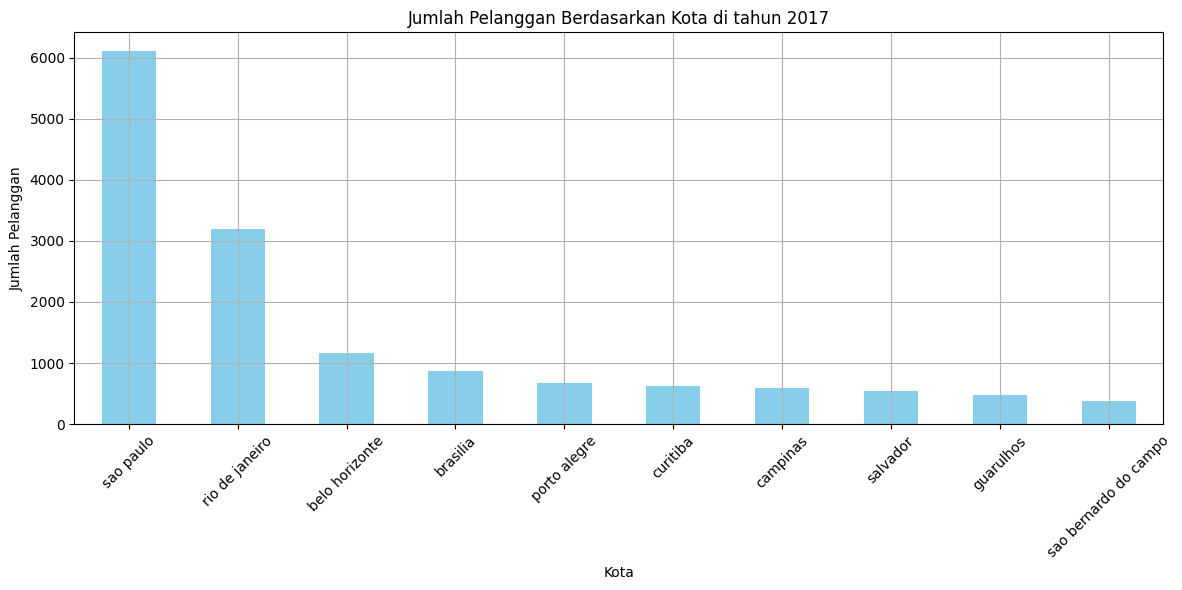

In [29]:
city_counts = df_2017['customer_city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
city_counts.plot(kind='bar', color='skyblue')

plt.title('Jumlah Pelanggan Berdasarkan Kota di tahun 2017')
plt.xlabel('Kota')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**Insight:**
- Analisis difokuskan pada pemfilteran tahun 2017,kemudian mengambil informasi bulan dari timestamp untuk melihat pola jumlah order, serta mengidentifikasi 10 kota dengan jumlah pelanggan terbanyak
- Pada jumlah order bulanan, order cenderung meningkat dari awal hingga akhir tahun, dengan puncak yang signifikan di bulan november.
- Pada jumlah order terbanyak di kota, Sao Paula sangat dominan dan memiliki perbedaan drastis di atas kota lain.

## Analisis Lanjutan (Opsional)

In [33]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (df['order_purchase_timestamp'].max() - x.max()).days,
    'order_id' : 'count'
})

rfm.columns = ['recency', 'frequency',]

rfm.head()

,recency,frequency
customer_id,,
00012a2ce6f8dcda20d059ce98491703,287,1
000161a058600d5901f007fab4c27140,409,1
0001fd6190edaaf884bcaf3d49edf079,547,1
0002414f95344307404f0ace7a26f1d5,378,1
000379cdec625522490c315e70c7a9fb,149,1


Pada hasil RFM analisi yang dilakukan, hanya diperoleh nilai recenry dan frequency, ini terjadi karena dataset yang digunakan belum mencakup informasi terkait nilai transaksi atau jumlah pembayaran dari setiap pelanggan.

## Conclusion

- **Conclution pertanyaan 1**
Berdasarkan hasil analisis, jumlah order selama tahun 2018 terlihat mengalami peningkatan dari awal sampai akhir tahun. Peningkatan paling tinggi terjadi di bulan November, yang kemungkinan besar dipengaruhi oleh event promosi besar. Kemudian terladi penurunan 28% di bulan desember. Secara keseluruhan, bisa disimpulkan bahwa ada pola musiman dalam transaksi, dan promo di waktu terentu.


- **Conclution pertanyaan 2**
Berdasarkan hasil analisis, terlihat bahwa pelanggan paling banyak berasal dari kota - kota besar, terutama Sao paula dan Rio De Janeiro. Di antara keduanya, Sao Paulo menjadi kota dengan jumlah pelanggan paling dominan di atas kota lainnya. Hal ini menunjukkan bahwa aktivitas E-Commerce masih terpusat di kota besar. Tapi di sisi lain, ini menjadi peluang, karena masih banyak kota lain yang potensinya belum maksimal.

In [35]:
df.to_csv("main_data.csv", index=False)